In [124]:
import sys
print(sys.executable)

c:\Users\ddaen\anaconda3\python.exe


In [125]:
import sys
!{sys.executable} -m pip install statsmodels

In [126]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib statsmodels scikit-learn openpyxl

In [127]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf


1. CSV 결과 파일 불러오기
2. 연봉 데이터 불러오기
3. pitcher_cluster_all에 연봉 merge
4. 클러스터별 연봉 요약
5. 회귀 결과로 좋은 클러스터 판단
6. 마이애미 부족 클러스터 계산
7. 보강 대상 클러스터 선정
8. 2025 후보군 생성
9. 최근 3년 성과 계산
10. 성과/비용/안정성 점수화
11. 선발 Top 5, 불펜 Top 5 추천
12. 최종 CSV 저장

In [128]:
DATA_DIR = Path(r"C:/Users/ddaen/OneDrive/Desktop/비어플/mlb_pitcher")

starter_cluster_result = pd.read_csv(DATA_DIR / "starter_cluster_result.csv")
reliever_cluster_result = pd.read_csv(DATA_DIR / "reliever_cluster_result.csv")
pitcher_cluster_all = pd.read_csv(DATA_DIR / "pitcher_cluster_all.csv")

team_cluster_wide = pd.read_csv(DATA_DIR / "team_cluster_wide.csv")
team_record_model = pd.read_csv(DATA_DIR / "team_record_model.csv")
team_model_data = pd.read_csv(DATA_DIR / "team_model_data.csv")
team_cluster_perf = pd.read_csv(DATA_DIR / "team_cluster_perf.csv")

starter_cluster_summary = pd.read_csv(DATA_DIR / "starter_cluster_summary.csv")
reliever_cluster_summary = pd.read_csv(DATA_DIR / "reliever_cluster_summary.csv")

In [129]:
# 연봉 데이터 파일 불러오기
salary_files = sorted(DATA_DIR.glob("mlb_pitcher_salaries_20*.csv"))
salary_files

[WindowsPath('C:/Users/ddaen/OneDrive/Desktop/비어플/mlb_pitcher/mlb_pitcher_salaries_2021.csv'),
 WindowsPath('C:/Users/ddaen/OneDrive/Desktop/비어플/mlb_pitcher/mlb_pitcher_salaries_2022.csv'),
 WindowsPath('C:/Users/ddaen/OneDrive/Desktop/비어플/mlb_pitcher/mlb_pitcher_salaries_2023.csv'),
 WindowsPath('C:/Users/ddaen/OneDrive/Desktop/비어플/mlb_pitcher/mlb_pitcher_salaries_2024.csv'),
 WindowsPath('C:/Users/ddaen/OneDrive/Desktop/비어플/mlb_pitcher/mlb_pitcher_salaries_2025.csv')]

In [130]:
# 이름 정리 함수
def clean_salary_name(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    x = re.sub(r"[*#]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

In [131]:
# 연도별 salary 파일 읽기 함수
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
        .str.strip("_")
    )
    return df


def parse_salary(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    x = x.replace("$", "").replace(",", "")
    return pd.to_numeric(x, errors="coerce")


def read_salary_one_year(file):
    year_match = re.search(r"20[0-9]{2}", file.name)
    year_from_file = int(year_match.group()) if year_match else np.nan
    
    df = pd.read_csv(file)
    df = clean_column_names(df)
    
    if "season" not in df.columns:
        df["season"] = year_from_file
    
    df["season"] = pd.to_numeric(df["season"], errors="coerce").astype("Int64")
    df["salary"] = df["salary"].apply(parse_salary)
    df["player_salary_name"] = df["player_name"].apply(clean_salary_name)
    df["salary_team"] = df["team"].replace({"ATH": "OAK"})
    
    df = df[[
        "season",
        "player_salary_name",
        "salary_team",
        "position",
        "salary"
    ]].rename(columns={
        "position": "salary_position"
    })
    
    return df

In [132]:
salary_all_raw = pd.concat(
    [read_salary_one_year(file) for file in salary_files],
    ignore_index=True
)

display(salary_all_raw.head())
display(salary_all_raw.info())

,season,player_salary_name,salary_team,salary_position,salary
0,2021,Gerrit Cole,NYY,SP,36000000
1,2021,Jacob deGrom,NYM,SP,36000000
2,2021,Zack Greinke,HOU,SP,35000000
3,2021,Stephen Strasburg,WSH,SP,35000000
4,2021,Max Scherzer,LAD,SP,34603480


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4232 entries, 0 to 4231
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   season              4232 non-null   Int64 
 1   player_salary_name  4232 non-null   object
 2   salary_team         4232 non-null   object
 3   salary_position     4232 non-null   object
 4   salary              4232 non-null   int64 
dtypes: Int64(1), int64(1), object(3)
memory usage: 169.6+ KB


None

In [133]:
# 선수-시즌 단위 연봉 데이터 생성
salary_player_year = (
    salary_all_raw
    .groupby(["season", "player_salary_name"], as_index=False)
    .agg(
        salary=("salary", "max"),
        salary_team=("salary_team", lambda x: "/".join(sorted(x.dropna().astype(str).unique()))),
        salary_position=("salary_position", lambda x: "/".join(sorted(x.dropna().astype(str).unique())))
    )
)

salary_player_year["salary_million"] = salary_player_year["salary"] / 1_000_000

display(salary_player_year.head())
display(salary_player_year["season"].value_counts().sort_index())

,season,player_salary_name,salary,salary_team,salary_position,salary_million
0,2021,A.J. Alexy,570500,TEX,P,0.5705
1,2021,A.J. Cole,1000000,TOR,RP,1.0000
2,2021,A.J. Minter,1300000,ATL,RP,1.3000
3,2021,A.J. Puk,570500,OAK,SP,0.5705
4,2021,A.J. Ramos,570500,LAA,RP,0.5705


season
2021    861
2022    827
2023    832
2024    828
2025    852
Name: count, dtype: Int64

In [134]:
# pitcher_cluster_all에 연봉 데이터 merge
pitcher_cluster_salary = pitcher_cluster_all.copy()

if "player_clean" in pitcher_cluster_salary.columns:
    name_col = "player_clean"
elif "player" in pitcher_cluster_salary.columns:
    name_col = "player"
elif "player_name" in pitcher_cluster_salary.columns:
    name_col = "player_name"
else:
    raise ValueError("선수 이름 컬럼이 없음: player_clean, player, player_name 중 하나 필요")

pitcher_cluster_salary["player_join_name"] = pitcher_cluster_salary[name_col].apply(clean_salary_name)
pitcher_cluster_salary["team"] = pitcher_cluster_salary["team"].replace({"ATH": "OAK"})

pitcher_cluster_salary = pitcher_cluster_salary.merge(
    salary_player_year,
    left_on=["season", "player_join_name"],
    right_on=["season", "player_salary_name"],
    how="left"
)

pitcher_cluster_salary["war_per_1m"] = (
    pitcher_cluster_salary["war"] / pitcher_cluster_salary["salary_million"]
)

pitcher_cluster_salary["salary_missing"] = pitcher_cluster_salary["salary"].isna()

In [135]:
# salary 매칭 확인
match_summary = pd.DataFrame({
    "n_total": [len(pitcher_cluster_salary)],
    "n_salary_matched": [pitcher_cluster_salary["salary"].notna().sum()],
    "n_salary_missing": [pitcher_cluster_salary["salary"].isna().sum()],
    "match_rate": [pitcher_cluster_salary["salary"].notna().mean()]
})

display(match_summary)

,n_total,n_salary_matched,n_salary_missing,match_rate
0,2726,2434,292,0.892883


In [136]:
# 클러스터별 연봉 summary
cluster_salary_summary = (
    pitcher_cluster_salary
    .dropna(subset=["salary"])
    .groupby(["role", "cluster"], as_index=False)
    .agg(
        n=("salary", "size"),
        salary_mean=("salary", "mean"),
        salary_median=("salary", "median"),
        salary_sd=("salary", "std"),
        salary_q1=("salary", lambda x: x.quantile(0.25)),
        salary_q3=("salary", lambda x: x.quantile(0.75)),
        salary_min=("salary", "min"),
        salary_max=("salary", "max"),
        war_mean=("war", "mean"),
        fip_mean=("fip", "mean"),
        whip_mean=("whip", "mean"),
        ip_mean=("ip", "mean"),
        war_per_1m_mean=("war_per_1m", "mean"),
        war_per_1m_median=("war_per_1m", "median")
    )
    .sort_values(["role", "cluster"])
)

display(cluster_salary_summary)

,role,cluster,n,salary_mean,salary_median,salary_sd,salary_q1,salary_q3,salary_min,salary_max,war_mean,fip_mean,whip_mean,ip_mean,war_per_1m_mean,war_per_1m_median
0,reliever,1,345,1.466322e+06,746600.0,2.204958e+06,713000.0,979500.0,570500.0,18000000.0,0.160290,4.538435,1.483159,37.552174,0.158927,0.131579
1,reliever,2,405,2.513894e+06,760000.0,4.023280e+06,714500.0,2250000.0,570500.0,40000000.0,1.064198,3.139975,1.080575,48.360000,1.006869,0.777778
2,reliever,3,537,1.648033e+06,747500.0,2.855465e+06,720000.0,1100000.0,570500.0,32000000.0,0.415829,4.059162,1.281780,45.260149,0.425162,0.263158
3,reliever,4,263,1.167654e+06,731100.0,1.727068e+06,700000.0,762850.0,570500.0,15300000.0,-0.254753,5.789962,1.586943,28.217871,-0.320498,-0.277778
4,starter,1,151,8.808768e+06,3800000.0,1.057405e+07,749050.0,14125000.0,570500.0,43333333.0,3.178146,3.202450,1.078483,131.684768,1.742438,0.666667
5,starter,2,259,5.808028e+06,779800.0,8.226292e+06,725625.0,8500000.0,570500.0,43333334.0,1.732046,4.057143,1.224004,122.864865,1.204696,0.524590
6,starter,3,190,3.944179e+06,760700.0,6.148807e+06,720000.0,3343750.0,570500.0,35416670.0,-0.158421,5.357211,1.514116,86.945263,-0.216284,-0.109289
7,starter,4,284,5.704821e+06,2000000.0,7.034076e+06,724375.0,8500000.0,570500.0,43333333.0,1.153169,4.402641,1.327415,120.321127,0.747994,0.228205


In [137]:
# 100만 달러 기준 연봉 summary
cluster_salary_summary_million = cluster_salary_summary.copy()

salary_cols = [
    "salary_mean",
    "salary_median",
    "salary_sd",
    "salary_q1",
    "salary_q3",
    "salary_min",
    "salary_max"
]

for col in salary_cols:
    cluster_salary_summary_million[col + "_m"] = (
        cluster_salary_summary_million[col] / 1_000_000
    )

cluster_salary_summary_million = cluster_salary_summary_million[[
    "role",
    "cluster",
    "n",
    "salary_mean_m",
    "salary_median_m",
    "salary_q1_m",
    "salary_q3_m",
    "salary_min_m",
    "salary_max_m",
    "war_mean",
    "fip_mean",
    "whip_mean",
    "ip_mean",
    "war_per_1m_mean",
    "war_per_1m_median"
]]

display(cluster_salary_summary_million)

,role,cluster,n,salary_mean_m,salary_median_m,salary_q1_m,salary_q3_m,salary_min_m,salary_max_m,war_mean,fip_mean,whip_mean,ip_mean,war_per_1m_mean,war_per_1m_median
0,reliever,1,345,1.466322,0.7466,0.713000,0.97950,0.5705,18.000000,0.160290,4.538435,1.483159,37.552174,0.158927,0.131579
1,reliever,2,405,2.513894,0.7600,0.714500,2.25000,0.5705,40.000000,1.064198,3.139975,1.080575,48.360000,1.006869,0.777778
2,reliever,3,537,1.648033,0.7475,0.720000,1.10000,0.5705,32.000000,0.415829,4.059162,1.281780,45.260149,0.425162,0.263158
3,reliever,4,263,1.167654,0.7311,0.700000,0.76285,0.5705,15.300000,-0.254753,5.789962,1.586943,28.217871,-0.320498,-0.277778
4,starter,1,151,8.808768,3.8000,0.749050,14.12500,0.5705,43.333333,3.178146,3.202450,1.078483,131.684768,1.742438,0.666667
5,starter,2,259,5.808028,0.7798,0.725625,8.50000,0.5705,43.333334,1.732046,4.057143,1.224004,122.864865,1.204696,0.524590
6,starter,3,190,3.944179,0.7607,0.720000,3.34375,0.5705,35.416670,-0.158421,5.357211,1.514116,86.945263,-0.216284,-0.109289
7,starter,4,284,5.704821,2.0000,0.724375,8.50000,0.5705,43.333333,1.153169,4.402641,1.327415,120.321127,0.747994,0.228205


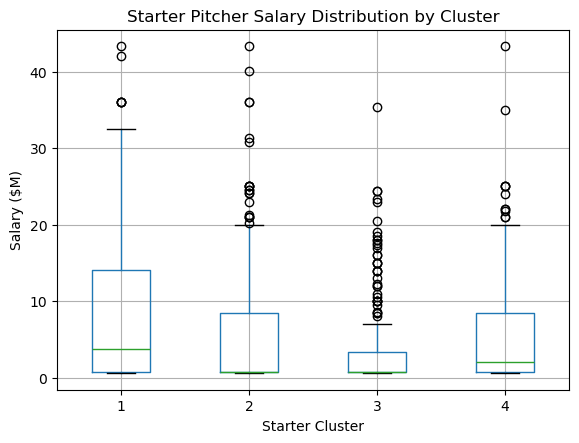

In [138]:
# 선발 salary 분포 그래프
starter_salary_plot = pitcher_cluster_salary[
    (pitcher_cluster_salary["role"] == "starter") &
    (pitcher_cluster_salary["salary"].notna())
].copy()

starter_salary_plot.boxplot(
    column="salary_million",
    by="cluster"
)

plt.title("Starter Pitcher Salary Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Starter Cluster")
plt.ylabel("Salary ($M)")
plt.show()

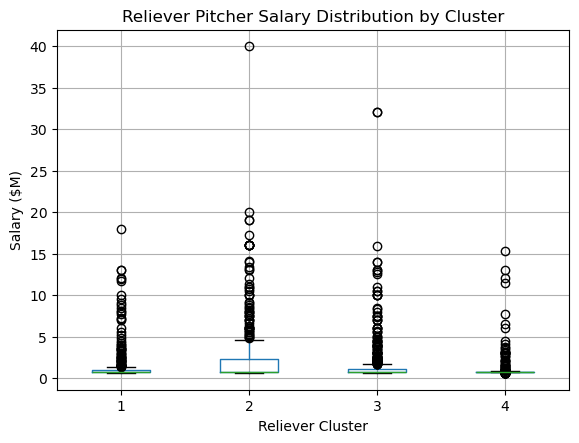

In [139]:
# 불펜 salary 분포 그래프
reliever_salary_plot = pitcher_cluster_salary[
    (pitcher_cluster_salary["role"] == "reliever") &
    (pitcher_cluster_salary["salary"].notna())
].copy()

reliever_salary_plot.boxplot(
    column="salary_million",
    by="cluster"
)

plt.title("Reliever Pitcher Salary Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Reliever Cluster")
plt.ylabel("Salary ($M)")
plt.show()

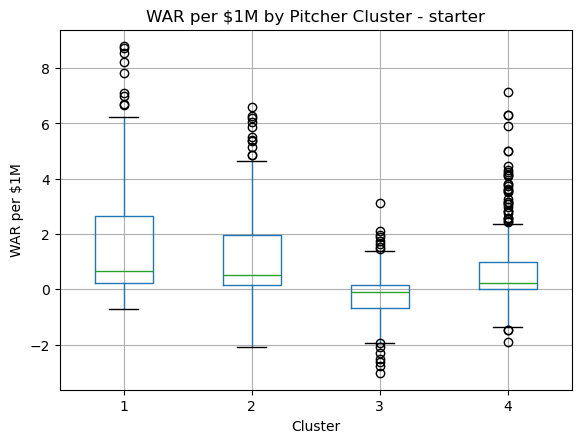

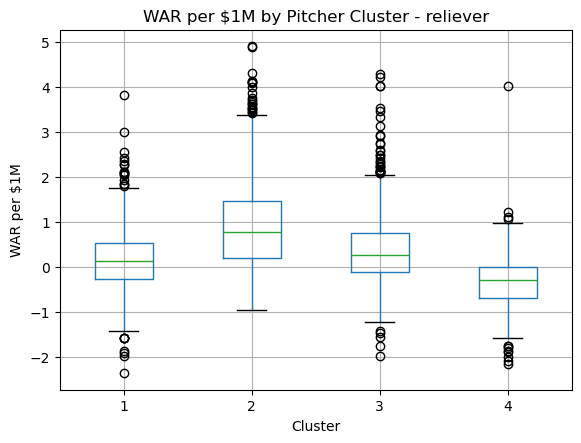

In [140]:
# 12. WAR per $1M 분포
war_value_plot = pitcher_cluster_salary[
    pitcher_cluster_salary["war_per_1m"].notna() &
    np.isfinite(pitcher_cluster_salary["war_per_1m"])
].copy()

for role in war_value_plot["role"].dropna().unique():
    temp = war_value_plot[war_value_plot["role"] == role]
    
    temp.boxplot(
        column="war_per_1m",
        by="cluster"
    )
    
    plt.title(f"WAR per $1M by Pitcher Cluster - {role}")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel("WAR per $1M")
    plt.show()

In [141]:
# 13. 2025시즌 클러스터별 연봉 summary
cluster_salary_2025_summary = (
    pitcher_cluster_salary
    .query("season == 2025")
    .dropna(subset=["salary"])
    .groupby(["role", "cluster"], as_index=False)
    .agg(
        n=("salary", "size"),
        salary_mean=("salary", "mean"),
        salary_median=("salary", "median"),
        salary_q1=("salary", lambda x: x.quantile(0.25)),
        salary_q3=("salary", lambda x: x.quantile(0.75)),
        war_mean=("war", "mean"),
        fip_mean=("fip", "mean"),
        whip_mean=("whip", "mean"),
        ip_mean=("ip", "mean"),
        war_per_1m_mean=("war_per_1m", "mean"),
        war_per_1m_median=("war_per_1m", "median")
    )
)

cluster_salary_2025_summary["salary_mean_m"] = cluster_salary_2025_summary["salary_mean"] / 1_000_000
cluster_salary_2025_summary["salary_median_m"] = cluster_salary_2025_summary["salary_median"] / 1_000_000
cluster_salary_2025_summary["salary_q1_m"] = cluster_salary_2025_summary["salary_q1"] / 1_000_000
cluster_salary_2025_summary["salary_q3_m"] = cluster_salary_2025_summary["salary_q3"] / 1_000_000

cluster_salary_2025_summary = cluster_salary_2025_summary.sort_values(["role", "cluster"])

display(cluster_salary_2025_summary)

,role,cluster,n,salary_mean,salary_median,salary_q1,salary_q3,war_mean,fip_mean,whip_mean,ip_mean,war_per_1m_mean,war_per_1m_median,salary_mean_m,salary_median_m,salary_q1_m,salary_q3_m
0,reliever,1,72,1.434455e+06,762250.0,760000.00,825000.0,0.236111,4.501806,1.485819,37.437500,0.280406,0.256234,1.434455,0.762250,0.760000,0.825000
1,reliever,2,63,2.707051e+06,815000.0,760000.00,2750000.0,1.076190,3.084921,1.078222,49.734921,0.853412,0.753623,2.707051,0.815000,0.760000,2.750000
2,reliever,3,117,1.642872e+06,773000.0,760000.00,1025000.0,0.461538,3.920855,1.266350,46.264103,0.477089,0.263158,1.642872,0.773000,0.760000,1.025000
3,reliever,4,52,1.292784e+06,761200.0,760000.00,773775.0,-0.350000,5.633846,1.595577,29.390385,-0.413608,-0.389676,1.292784,0.761200,0.760000,0.773775
4,starter,1,30,9.951550e+06,5666666.5,927083.25,14312500.0,2.813333,3.181667,1.096000,109.986667,1.066833,0.491430,9.951550,5.666666,0.927083,14.312500
5,starter,2,66,7.137114e+06,2137500.0,767700.00,11625000.0,1.612121,4.073485,1.226864,116.790909,0.885438,0.339080,7.137114,2.137500,0.767700,11.625000
6,starter,3,41,4.362818e+06,770000.0,761500.00,3950000.0,0.063415,5.188537,1.441537,97.385366,-0.088834,-0.041667,4.362818,0.770000,0.761500,3.950000
7,starter,4,41,7.905459e+06,2950000.0,770000.00,16000000.0,1.370732,4.272195,1.297488,127.278049,0.711649,0.146154,7.905459,2.950000,0.770000,16.000000


In [142]:
# 14. 회귀모형 다시 만들기
model_ra_pg = smf.ols(
    """
    runs_allowed_per_game ~ 
    starter_c1_ip_share + starter_c2_ip_share + starter_c4_ip_share +
    reliever_c1_ip_share + reliever_c2_ip_share + reliever_c3_ip_share +
    C(season)
    """,
    data=team_model_data
).fit()

model_run_diff = smf.ols(
    """
    run_diff_per_game ~ 
    starter_c1_ip_share + starter_c2_ip_share + starter_c4_ip_share +
    reliever_c1_ip_share + reliever_c2_ip_share + reliever_c3_ip_share +
    C(season)
    """,
    data=team_model_data
).fit()

model_win_pct = smf.ols(
    """
    win_pct ~ 
    starter_c1_ip_share + starter_c2_ip_share + starter_c4_ip_share +
    reliever_c1_ip_share + reliever_c2_ip_share + reliever_c3_ip_share +
    C(season)
    """,
    data=team_model_data
).fit()

In [143]:
# 15. 회귀 결과 정리
def tidy_model(model, model_name):
    result = pd.DataFrame({
        "term": model.params.index,
        "estimate": model.params.values,
        "std_error": model.bse.values,
        "statistic": model.tvalues.values,
        "p_value": model.pvalues.values
    })
    result["model"] = model_name
    return result


reg_priority = pd.concat([
    tidy_model(model_ra_pg, "runs_allowed_per_game"),
    tidy_model(model_run_diff, "run_diff_per_game"),
    tidy_model(model_win_pct, "win_pct")
], ignore_index=True)

reg_priority = reg_priority[
    reg_priority["term"].str.contains("_ip_share", na=False)
].copy()

reg_priority["role"] = reg_priority["term"].str.extract(r"(starter|reliever)")
reg_priority["cluster"] = reg_priority["term"].str.extract(r"c([0-9])")

reg_priority["good_direction"] = np.select(
    [
        (reg_priority["model"] == "runs_allowed_per_game") & (reg_priority["estimate"] < 0),
        (reg_priority["model"] == "run_diff_per_game") & (reg_priority["estimate"] > 0),
        (reg_priority["model"] == "win_pct") & (reg_priority["estimate"] > 0)
    ],
    [1, 1, 1],
    default=0
)

reg_priority["significant_10"] = (reg_priority["p_value"] < 0.10).astype(int)
reg_priority["significant_05"] = (reg_priority["p_value"] < 0.05).astype(int)

display(reg_priority)

,term,estimate,std_error,statistic,p_value,model,role,cluster,good_direction,significant_10,significant_05
4,starter_c1_ip_share,-1.454121,0.213415,-6.813574,5.309726e-10,runs_allowed_per_game,starter,1,1,1,1
5,starter_c2_ip_share,-0.975766,0.191697,-5.090137,1.488864e-06,runs_allowed_per_game,starter,2,1,1,1
6,starter_c4_ip_share,-0.820099,0.186503,-4.397252,2.542021e-05,runs_allowed_per_game,starter,4,1,1,1
7,reliever_c1_ip_share,-0.385703,0.376824,-1.023563,3.082873e-01,runs_allowed_per_game,reliever,1,1,0,0
8,reliever_c2_ip_share,-1.662499,0.315262,-5.273393,6.760819e-07,runs_allowed_per_game,reliever,2,1,1,1
9,reliever_c3_ip_share,-0.947159,0.315297,-3.004017,3.299530e-03,runs_allowed_per_game,reliever,3,1,1,1
14,starter_c1_ip_share,2.478533,0.353517,7.011077,2.011622e-10,run_diff_per_game,starter,1,1,1,1
15,starter_c2_ip_share,1.485295,0.317542,4.677479,8.309895e-06,run_diff_per_game,starter,2,1,1,1
16,starter_c4_ip_share,1.392075,0.308936,4.506025,1.655232e-05,run_diff_per_game,starter,4,1,1,1
17,reliever_c1_ip_share,-0.687845,0.624199,-1.101964,2.728825e-01,run_diff_per_game,reliever,1,0,0,0


In [144]:
# 16. 회귀 우선순위 점수
cluster_reg_score = (
    reg_priority
    .groupby(["role", "cluster"], as_index=False)
    .agg(
        reg_good_direction_count=("good_direction", "sum"),
        reg_significant_10_count=("significant_10", "sum"),
        reg_significant_05_count=("significant_05", "sum")
    )
)

for model_name, prefix in [
    ("runs_allowed_per_game", "ra_pg"),
    ("run_diff_per_game", "run_diff"),
    ("win_pct", "win_pct")
]:
    temp = (
        reg_priority
        .query("model == @model_name")
        [["role", "cluster", "estimate", "p_value"]]
        .rename(columns={
            "estimate": f"{prefix}_estimate",
            "p_value": f"{prefix}_pvalue"
        })
    )
    
    cluster_reg_score = cluster_reg_score.merge(
        temp,
        on=["role", "cluster"],
        how="left"
    )

display(cluster_reg_score)

,role,cluster,reg_good_direction_count,reg_significant_10_count,reg_significant_05_count,ra_pg_estimate,ra_pg_pvalue,run_diff_estimate,run_diff_pvalue,win_pct_estimate,win_pct_pvalue
0,reliever,1,1,1,1,-0.385703,3.082873e-01,-0.687845,2.728825e-01,-0.124189,4.976933e-02
1,reliever,2,3,3,3,-1.662499,6.760819e-07,1.742379,1.157883e-03,0.171502,1.415377e-03
2,reliever,3,3,1,1,-0.947159,3.299530e-03,0.323125,5.374070e-01,0.006542,9.008418e-01
3,starter,1,3,3,3,-1.454121,5.309726e-10,2.478533,2.011622e-10,0.199355,1.440888e-07
4,starter,2,3,3,3,-0.975766,1.488864e-06,1.485295,8.309895e-06,0.117698,3.434596e-04
5,starter,4,3,3,3,-0.820099,2.542021e-05,1.392075,1.655232e-05,0.106277,8.504832e-04


In [145]:
# 17. 마이애미 부족 클러스터 계산
cluster_cols = [c for c in team_cluster_perf.columns if "_ip_share" in c]

win500_cluster_profile = (
    team_cluster_perf
    .query("win_pct >= 0.5")
    [cluster_cols]
    .mean()
)

miami_cluster_profile = (
    team_cluster_perf
    .query("team == 'MIA'")
    [cluster_cols]
    .mean()
)

cluster_gap_mia_vs_win500 = pd.DataFrame({
    "role_cluster": cluster_cols,
    "WinPct_500_plus": win500_cluster_profile.values,
    "MIA": miami_cluster_profile.values
})

cluster_gap_mia_vs_win500["gap_mia_minus_win500"] = (
    cluster_gap_mia_vs_win500["MIA"] -
    cluster_gap_mia_vs_win500["WinPct_500_plus"]
)

cluster_gap_mia_vs_win500["gap_pct_point"] = (
    cluster_gap_mia_vs_win500["gap_mia_minus_win500"] * 100
)

cluster_gap_mia_vs_win500 = cluster_gap_mia_vs_win500.sort_values("gap_pct_point")

display(cluster_gap_mia_vs_win500)

,role_cluster,WinPct_500_plus,MIA,gap_mia_minus_win500,gap_pct_point
5,starter_c4_ip_share,0.328255,0.172858,-0.155397,-15.539698
6,reliever_c2_ip_share,0.396870,0.276864,-0.120006,-12.000616
7,starter_c1_ip_share,0.243421,0.147023,-0.096398,-9.639816
1,reliever_c3_ip_share,0.357878,0.350620,-0.007258,-0.725817
2,reliever_c4_ip_share,0.083812,0.143543,0.059731,5.973070
0,reliever_c1_ip_share,0.161440,0.228974,0.067534,6.753364
3,starter_c2_ip_share,0.348158,0.462199,0.114041,11.404111
4,starter_c3_ip_share,0.080166,0.217920,0.137754,13.775404


In [146]:
# 18. 마이애미 부족 클러스터 정리
mia_need_cluster = cluster_gap_mia_vs_win500.copy()

mia_need_cluster["role"] = mia_need_cluster["role_cluster"].str.extract(r"(starter|reliever)")
mia_need_cluster["cluster"] = mia_need_cluster["role_cluster"].str.extract(r"c([0-9])")

mia_need_cluster["need_type"] = np.select(
    [
        mia_need_cluster["gap_pct_point"] < 0,
        mia_need_cluster["gap_pct_point"] > 0
    ],
    [
        "MIA 부족",
        "MIA 과잉"
    ],
    default="비슷함"
)

mia_need_cluster["shortage_score"] = np.where(
    mia_need_cluster["gap_pct_point"] < 0,
    mia_need_cluster["gap_pct_point"].abs(),
    0
)

mia_need_cluster = mia_need_cluster.merge(
    cluster_reg_score,
    on=["role", "cluster"],
    how="left"
)


def get_cluster_quality(row):
    role = row["role"]
    cluster = str(row["cluster"])
    
    if role == "starter" and cluster == "1":
        return "elite"
    elif role == "starter" and cluster == "2":
        return "good"
    elif role == "starter" and cluster == "4":
        return "middle"
    elif role == "starter" and cluster == "3":
        return "bad"
    elif role == "reliever" and cluster == "2":
        return "elite"
    elif role == "reliever" and cluster == "3":
        return "good"
    elif role == "reliever" and cluster == "1":
        return "risky_middle"
    elif role == "reliever" and cluster == "4":
        return "bad"
    else:
        return "check"


mia_need_cluster["cluster_quality"] = mia_need_cluster.apply(get_cluster_quality, axis=1)

mia_need_cluster["recommend_cluster"] = np.select(
    [
        (
            (mia_need_cluster["need_type"] == "MIA 부족") &
            (mia_need_cluster["cluster_quality"] != "bad") &
            (mia_need_cluster["ra_pg_estimate"].notna()) &
            (mia_need_cluster["ra_pg_estimate"] < 0) &
            (mia_need_cluster["ra_pg_pvalue"] < 0.10)
        ),
        (
            (mia_need_cluster["need_type"] == "MIA 부족") &
            (mia_need_cluster["cluster_quality"] != "bad")
        )
    ],
    [
        "최우선 보강",
        "보강 후보"
    ],
    default="비추천 또는 낮은 우선순위"
)

mia_need_cluster = mia_need_cluster.sort_values("shortage_score", ascending=False)

display(mia_need_cluster)

,role_cluster,WinPct_500_plus,MIA,gap_mia_minus_win500,gap_pct_point,role,cluster,need_type,shortage_score,reg_good_direction_count,reg_significant_10_count,reg_significant_05_count,ra_pg_estimate,ra_pg_pvalue,run_diff_estimate,run_diff_pvalue,win_pct_estimate,win_pct_pvalue,cluster_quality,recommend_cluster
0,starter_c4_ip_share,0.328255,0.172858,-0.155397,-15.539698,starter,4,MIA 부족,15.539698,3.0,3.0,3.0,-0.820099,2.542021e-05,1.392075,1.655232e-05,0.106277,8.504832e-04,middle,최우선 보강
1,reliever_c2_ip_share,0.396870,0.276864,-0.120006,-12.000616,reliever,2,MIA 부족,12.000616,3.0,3.0,3.0,-1.662499,6.760819e-07,1.742379,1.157883e-03,0.171502,1.415377e-03,elite,최우선 보강
2,starter_c1_ip_share,0.243421,0.147023,-0.096398,-9.639816,starter,1,MIA 부족,9.639816,3.0,3.0,3.0,-1.454121,5.309726e-10,2.478533,2.011622e-10,0.199355,1.440888e-07,elite,최우선 보강
3,reliever_c3_ip_share,0.357878,0.350620,-0.007258,-0.725817,reliever,3,MIA 부족,0.725817,3.0,1.0,1.0,-0.947159,3.299530e-03,0.323125,5.374070e-01,0.006542,9.008418e-01,good,최우선 보강
4,reliever_c4_ip_share,0.083812,0.143543,0.059731,5.973070,reliever,4,MIA 과잉,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bad,비추천 또는 낮은 우선순위
5,reliever_c1_ip_share,0.161440,0.228974,0.067534,6.753364,reliever,1,MIA 과잉,0.000000,1.0,1.0,1.0,-0.385703,3.082873e-01,-0.687845,2.728825e-01,-0.124189,4.976933e-02,risky_middle,비추천 또는 낮은 우선순위
6,starter_c2_ip_share,0.348158,0.462199,0.114041,11.404111,starter,2,MIA 과잉,0.000000,3.0,3.0,3.0,-0.975766,1.488864e-06,1.485295,8.309895e-06,0.117698,3.434596e-04,good,비추천 또는 낮은 우선순위
7,starter_c3_ip_share,0.080166,0.217920,0.137754,13.775404,starter,3,MIA 과잉,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bad,비추천 또는 낮은 우선순위


In [147]:
# 19. 최종 추천 대상 클러스터
target_clusters = (
    mia_need_cluster
    .query("recommend_cluster in ['최우선 보강', '보강 후보']")
    [[
        "role",
        "cluster",
        "role_cluster",
        "gap_pct_point",
        "shortage_score",
        "cluster_quality",
        "recommend_cluster",
        "ra_pg_estimate",
        "ra_pg_pvalue",
        "run_diff_estimate",
        "run_diff_pvalue",
        "win_pct_estimate",
        "win_pct_pvalue"
    ]]
    .copy()
)

display(target_clusters)

,role,cluster,role_cluster,gap_pct_point,shortage_score,cluster_quality,recommend_cluster,ra_pg_estimate,ra_pg_pvalue,run_diff_estimate,run_diff_pvalue,win_pct_estimate,win_pct_pvalue
0,starter,4,starter_c4_ip_share,-15.539698,15.539698,middle,최우선 보강,-0.820099,2.542021e-05,1.392075,1.655232e-05,0.106277,8.504832e-04
1,reliever,2,reliever_c2_ip_share,-12.000616,12.000616,elite,최우선 보강,-1.662499,6.760819e-07,1.742379,1.157883e-03,0.171502,1.415377e-03
2,starter,1,starter_c1_ip_share,-9.639816,9.639816,elite,최우선 보강,-1.454121,5.309726e-10,2.478533,2.011622e-10,0.199355,1.440888e-07
3,reliever,3,reliever_c3_ip_share,-0.725817,0.725817,good,최우선 보강,-0.947159,3.299530e-03,0.323125,5.374070e-01,0.006542,9.008418e-01


In [148]:
# 20. 최근 3년 성과 계산
recent_df = pitcher_cluster_salary[
    pitcher_cluster_salary["season"].isin([2023, 2024, 2025]) &
    pitcher_cluster_salary["player_join_name"].notna() &
    pitcher_cluster_salary["role"].notna()
].copy()

recent_df["season_weight"] = recent_df["season"].map({
    2025: 0.5,
    2024: 0.3,
    2023: 0.2
}).fillna(0)

recent_df["ip_weight"] = recent_df["ip"].fillna(0)
recent_df["weighted_ip"] = recent_df["season_weight"] * recent_df["ip_weight"]


def weighted_summary(g):
    war_valid = g["war"].notna()
    fip_valid = g["fip"].notna()
    whip_valid = g["whip"].notna()
    
    war_den = g.loc[war_valid, "season_weight"].sum()
    fip_den = g.loc[fip_valid, "weighted_ip"].sum()
    whip_den = g.loc[whip_valid, "weighted_ip"].sum()
    
    return pd.Series({
        "recent_n_seasons": g["season"].nunique(),
        "recent_war_weighted": (
            (g.loc[war_valid, "war"] * g.loc[war_valid, "season_weight"]).sum() / war_den
            if war_den > 0 else np.nan
        ),
        "recent_fip_weighted": (
            (g.loc[fip_valid, "fip"] * g.loc[fip_valid, "weighted_ip"]).sum() / fip_den
            if fip_den > 0 else np.nan
        ),
        "recent_whip_weighted": (
            (g.loc[whip_valid, "whip"] * g.loc[whip_valid, "weighted_ip"]).sum() / whip_den
            if whip_den > 0 else np.nan
        ),
        "recent_ip_total": g["ip"].sum(skipna=True),
        "recent_ip_weighted": (g["ip"].fillna(0) * g["season_weight"]).sum(),
        "recent_war_sum": g["war"].sum(skipna=True)
    })


recent_player_form = (
    recent_df
    .groupby(["player_join_name", "role"])
    .apply(weighted_summary)
    .reset_index()
)

display(recent_player_form.head())

C:\Users\ddaen\AppData\Local\Temp\ipykernel_37124\2088394930.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_summary)


,player_join_name,role,recent_n_seasons,recent_war_weighted,recent_fip_weighted,recent_whip_weighted,recent_ip_total,recent_ip_weighted,recent_war_sum
0,A.J. Minter,reliever,3.0,0.6900,3.272121,1.092643,109.3,28.57,2.3
1,A.J. Puk,reliever,1.0,0.8000,3.590000,1.182000,56.2,11.24,0.8
2,AJ Blubaugh,reliever,1.0,0.7000,4.420000,0.875000,32.0,16.00,0.7
3,AJ Smith-Shawver,starter,1.0,0.4000,3.900000,1.421000,44.1,22.05,0.4
4,Aaron Ashby,reliever,2.0,1.2625,2.722328,1.147469,94.3,41.53,2.1


# 추가: 3년 가중치 0.5 / 0.3 / 0.2 민감도 분석 
- 기존 0.5 / 0.3 / 0.2 기준이 결과에 과도하게 영향을 주는지 확인
- 결과:  기존의 0.5/0.3/0.2 기준은 다른 가중치 방식들과 높은 상관관계를 보였다. 따라서 특정 가중치 설정에 따라 결과가 크게 달라지지는 않았으며, 본 분석의 최근 3년 가중 성과 지표는 안정적인 평가 기준으로 볼 수 있다. 이는 3년 가중치가 불필요하다는 의미가 아니라, 최근 성과를 반영하는 여러 합리적 기준 중 어떤 방식을 사용해도 선수 평가의 큰 흐름은 유사하다는 의미이다.

In [149]:
from functools import reduce

def make_recent_player_form_with_weights(df, weights, label):
    temp = df[
        df["season"].isin(list(weights.keys())) &
        df["player_join_name"].notna() &
        df["role"].notna()
    ].copy()
    
    temp["season_weight"] = temp["season"].map(weights).fillna(0)
    temp["ip_weight"] = temp["ip"].fillna(0)
    temp["weighted_ip"] = temp["season_weight"] * temp["ip_weight"]
    
    def weighted_summary_alt(g):
        war_valid = g["war"].notna()
        fip_valid = g["fip"].notna()
        whip_valid = g["whip"].notna()
        
        war_den = g.loc[war_valid, "season_weight"].sum()
        fip_den = g.loc[fip_valid, "weighted_ip"].sum()
        whip_den = g.loc[whip_valid, "weighted_ip"].sum()
        
        return pd.Series({
            f"recent_war_{label}": (
                (g.loc[war_valid, "war"] * g.loc[war_valid, "season_weight"]).sum() / war_den
                if war_den > 0 else np.nan
            ),
            f"recent_fip_{label}": (
                (g.loc[fip_valid, "fip"] * g.loc[fip_valid, "weighted_ip"]).sum() / fip_den
                if fip_den > 0 else np.nan
            ),
            f"recent_whip_{label}": (
                (g.loc[whip_valid, "whip"] * g.loc[whip_valid, "weighted_ip"]).sum() / whip_den
                if whip_den > 0 else np.nan
            )
        })
    
    return (
        temp
        .groupby(["player_join_name", "role"])
        .apply(weighted_summary_alt)
        .reset_index()
    )


weight_scenarios = {
    "equal_333": {
        2025: 1/3,
        2024: 1/3,
        2023: 1/3
    },
    "base_532": {
        2025: 0.5,
        2024: 0.3,
        2023: 0.2
    },
    "current_heavy_631": {
        2025: 0.6,
        2024: 0.3,
        2023: 0.1
    },
    "two_year_73": {
        2025: 0.7,
        2024: 0.3,
        2023: 0.0
    }
}

recent_sensitivity_list = [
    make_recent_player_form_with_weights(
        pitcher_cluster_salary,
        weights,
        label
    )
    for label, weights in weight_scenarios.items()
]

recent_sensitivity = reduce(
    lambda left, right: pd.merge(left, right, on=["player_join_name", "role"], how="outer"),
    recent_sensitivity_list
)

display(recent_sensitivity.head())

C:\Users\ddaen\AppData\Local\Temp\ipykernel_37124\2532948148.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_summary_alt)
C:\Users\ddaen\AppData\Local\Temp\ipykernel_37124\2532948148.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_summary_alt)
C:\Users\ddaen\AppData\Local\Temp\ipykernel_37124\2532948148.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on t

,player_join_name,role,recent_war_equal_333,recent_fip_equal_333,recent_whip_equal_333,recent_war_base_532,recent_fip_base_532,recent_whip_base_532,recent_war_current_heavy_631,recent_fip_current_heavy_631,recent_whip_current_heavy_631,recent_war_two_year_73,recent_fip_two_year_73,recent_whip_two_year_73
0,A.J. Minter,reliever,0.766667,3.287969,1.118116,0.6900,3.272121,1.092643,0.650000,3.312323,1.061101,0.61,3.376380,1.010840
1,A.J. Puk,reliever,0.800000,3.590000,1.182000,0.8000,3.590000,1.182000,0.800000,3.590000,1.182000,NaN,NaN,NaN
2,AJ Blubaugh,reliever,0.700000,4.420000,0.875000,0.7000,4.420000,0.875000,0.700000,4.420000,0.875000,0.70,4.420000,0.875000
3,AJ Smith-Shawver,starter,0.400000,3.900000,1.421000,0.4000,3.900000,1.421000,0.400000,3.900000,1.421000,0.40,3.900000,1.421000
4,Aaron Ashby,reliever,1.050000,2.732778,1.136924,1.2625,2.722328,1.147469,1.333333,2.719259,1.150566,1.39,2.716931,1.152915


In [150]:
# 가중치별 WAR 결과가 얼마나 비슷한지 확인
war_sensitivity_cols = [
    "recent_war_equal_333",
    "recent_war_base_532",
    "recent_war_current_heavy_631",
    "recent_war_two_year_73"
]

war_sensitivity_corr = recent_sensitivity[war_sensitivity_cols].corr()

display(war_sensitivity_corr)

,recent_war_equal_333,recent_war_base_532,recent_war_current_heavy_631,recent_war_two_year_73
recent_war_equal_333,1.000000,0.987539,0.964643,0.910371
recent_war_base_532,0.987539,1.000000,0.993473,0.963796
recent_war_current_heavy_631,0.964643,0.993473,1.000000,0.988949
recent_war_two_year_73,0.910371,0.963796,0.988949,1.000000


# 추가: 2021~2025 WAR 변화 추이 반영 - 1
- WAR 추세 계산


In [151]:
# WAR 추세 계산
# 선수별, role별 WAR 선형 추세 slope 계산
# slope > 0 : WAR 우상향
# slope < 0 : WAR 우하향
# ------------------------------------------------------------

war_trend_base = pitcher_cluster_salary[
    pitcher_cluster_salary["season"].between(2021, 2025) &
    pitcher_cluster_salary["player_join_name"].notna() &
    pitcher_cluster_salary["role"].notna() &
    pitcher_cluster_salary["war"].notna()
].copy()


def calc_war_trend(g):
    g = g.sort_values("season").copy()
    
    # 최소 3시즌 이상 기록이 있어야 추세 판단
    if g["season"].nunique() < 3:
        return pd.Series({
            "war_trend_slope": np.nan,
            "war_trend_n_seasons": g["season"].nunique(),
            "war_2021_2025_mean": g["war"].mean(),
            "war_2021_2025_sum": g["war"].sum(),
            "war_2021_2025_first": g["war"].iloc[0],
            "war_2021_2025_last": g["war"].iloc[-1]
        })
    
    x = g["season"].astype(float).values
    y = g["war"].astype(float).values
    
    # year 값이 너무 크니까 중심화
    x_centered = x - x.mean()
    
    slope = np.polyfit(x_centered, y, 1)[0]
    
    return pd.Series({
        "war_trend_slope": slope,
        "war_trend_n_seasons": g["season"].nunique(),
        "war_2021_2025_mean": g["war"].mean(),
        "war_2021_2025_sum": g["war"].sum(),
        "war_2021_2025_first": g["war"].iloc[0],
        "war_2021_2025_last": g["war"].iloc[-1]
    })


war_trend_features = (
    war_trend_base
    .groupby(["player_join_name", "role"])
    .apply(calc_war_trend)
    .reset_index()
)

war_trend_features["war_trend_direction"] = np.select(
    [
        war_trend_features["war_trend_slope"] > 0.2,
        war_trend_features["war_trend_slope"] < -0.2
    ],
    [
        "우상향",
        "우하향"
    ],
    default="유지 또는 약한 변화"
)

display(war_trend_features.head())

C:\Users\ddaen\AppData\Local\Temp\ipykernel_37124\2220807503.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_war_trend)


,player_join_name,role,war_trend_slope,war_trend_n_seasons,war_2021_2025_mean,war_2021_2025_sum,war_2021_2025_first,war_2021_2025_last,war_trend_direction
0,A.J. Alexy,reliever,NaN,1.0,0.10,0.1,0.1,0.1,유지 또는 약한 변화
1,A.J. Minter,reliever,-0.04,5.0,0.88,4.4,0.2,0.4,유지 또는 약한 변화
2,A.J. Puk,reliever,0.45,3.0,0.60,1.8,-0.1,0.8,우상향
3,AJ Blubaugh,reliever,NaN,1.0,0.70,0.7,0.7,0.7,유지 또는 약한 변화
4,AJ Smith-Shawver,starter,NaN,1.0,0.40,0.4,0.4,0.4,유지 또는 약한 변화


In [152]:
# 21. 보강 대상 클러스터 우선순위
target_clusters_b = target_clusters.copy()

target_clusters_b["cluster_priority"] = np.select(
    [
        target_clusters_b["recommend_cluster"] == "최우선 보강",
        target_clusters_b["recommend_cluster"] == "보강 후보"
    ],
    [2, 1],
    default=0
)

target_clusters_b = target_clusters_b.sort_values(
    ["cluster_priority", "shortage_score"],
    ascending=[False, False]
)

display(target_clusters_b)

,role,cluster,role_cluster,gap_pct_point,shortage_score,cluster_quality,recommend_cluster,ra_pg_estimate,ra_pg_pvalue,run_diff_estimate,run_diff_pvalue,win_pct_estimate,win_pct_pvalue,cluster_priority
0,starter,4,starter_c4_ip_share,-15.539698,15.539698,middle,최우선 보강,-0.820099,2.542021e-05,1.392075,1.655232e-05,0.106277,8.504832e-04,2
1,reliever,2,reliever_c2_ip_share,-12.000616,12.000616,elite,최우선 보강,-1.662499,6.760819e-07,1.742379,1.157883e-03,0.171502,1.415377e-03,2
2,starter,1,starter_c1_ip_share,-9.639816,9.639816,elite,최우선 보강,-1.454121,5.309726e-10,2.478533,2.011622e-10,0.199355,1.440888e-07,2
3,reliever,3,reliever_c3_ip_share,-0.725817,0.725817,good,최우선 보강,-0.947159,3.299530e-03,0.323125,5.374070e-01,0.006542,9.008418e-01,2


In [153]:
# 22. 2025 후보군 만들기
pitcher_cluster_salary["cluster"] = pitcher_cluster_salary["cluster"].astype(str)
target_clusters_b["cluster"] = target_clusters_b["cluster"].astype(str)

candidate_2025_b = (
    pitcher_cluster_salary
    .query("season == 2025 and team != 'MIA'")
    .dropna(subset=["salary", "war", "fip", "whip", "ip"])
    .merge(
        target_clusters_b,
        on=["role", "cluster"],
        how="inner"
    )
    .merge(
        recent_player_form,
        on=["player_join_name", "role"],
        how="left"
    )
)

candidate_2025_b["salary_million"] = candidate_2025_b["salary"] / 1_000_000
candidate_2025_b["war_per_1m_2025"] = candidate_2025_b["war"] / candidate_2025_b["salary_million"]
candidate_2025_b["recent_war_per_1m"] = candidate_2025_b["recent_war_weighted"] / candidate_2025_b["salary_million"]

display(
    candidate_2025_b
    .groupby(["role", "cluster", "cluster_quality", "recommend_cluster"])
    .size()
    .reset_index(name="n")
)

,role,cluster,cluster_quality,recommend_cluster,n
0,reliever,2,elite,최우선 보강,62
1,reliever,3,good,최우선 보강,113
2,starter,1,elite,최우선 보강,30
3,starter,4,middle,최우선 보강,40


# 추가: 2021~2025 WAR 변화 추이 반영 - 2
- 후보군에 WAR 추세 붙이기

In [154]:
# ------------------------------------------------------------
# 후보군에 2021~2025 WAR 추세 변수 결합
# ------------------------------------------------------------

candidate_2025_b = candidate_2025_b.merge(
    war_trend_features,
    on=["player_join_name", "role"],
    how="left"
)

display(candidate_2025_b[[
    "player_join_name",
    "role",
    "cluster",
    "war",
    "recent_war_weighted",
    "war_trend_slope",
    "war_trend_direction",
    "war_trend_n_seasons"
]].head())

,player_join_name,role,cluster,war,recent_war_weighted,war_trend_slope,war_trend_direction,war_trend_n_seasons
0,Andre Pallante,starter,4,-1.1,-0.087500,NaN,유지 또는 약한 변화,2.0
1,Andrew Abbott,starter,4,5.5,4.280000,1.400000e+00,우상향,3.0
2,Blake Snell,starter,1,1.4,2.660000,-2.420181e-17,유지 또는 약한 변화,5.0
3,Brandon Walter,starter,1,1.3,1.300000,NaN,유지 또는 약한 변화,1.0
4,Brandon Woodruff,starter,1,1.2,1.514286,-9.428571e-01,우하향,4.0


# 추가: 연봉 이상치가 많을 때 median, Q1, Q3 방식 보완 - 1
- 연봉 percentile 기반 점수 만들기

In [155]:
# ------------------------------------------------------------
# 연봉 이상치 보완: 같은 role-cluster 안에서 연봉 percentile 계산
# salary_pct_in_cluster가 낮을수록 저연봉
# ------------------------------------------------------------

candidate_2025_b["salary_pct_in_cluster"] = (
    candidate_2025_b
    .groupby(["role", "cluster"])["salary"]
    .rank(pct=True, method="average")
)

# 낮은 연봉일수록 높은 점수
# 0~3점 범위
candidate_2025_b["salary_score_percentile"] = (
    1 - candidate_2025_b["salary_pct_in_cluster"]
) * 3

# 로그 연봉도 확인용으로 생성
candidate_2025_b["log_salary_million"] = np.log1p(candidate_2025_b["salary_million"])

display(candidate_2025_b[[
    "player_join_name",
    "role",
    "cluster",
    "salary_million",
    "salary_pct_in_cluster",
    "salary_score_percentile"
]].head())

,player_join_name,role,cluster,salary_million,salary_pct_in_cluster,salary_score_percentile
0,Andre Pallante,starter,4,2.100000,0.375000,1.875
1,Andrew Abbott,starter,4,0.770000,0.250000,2.250
2,Blake Snell,starter,1,28.436867,0.933333,0.200
3,Brandon Walter,starter,1,0.760000,0.083333,2.750
4,Brandon Woodruff,starter,1,5.000000,0.500000,1.500


In [156]:
# 23. 클러스터별 benchmark 만들기
bench_rows = []

for (role, cluster), g in candidate_2025_b.groupby(["role", "cluster"]):
    pos_recent = g[g["recent_war_weighted"] > 0]
    
    bench_rows.append({
        "role": role,
        "cluster": cluster,
        "n_cluster_candidates": len(g),
        
        "salary_q1": g["salary"].quantile(0.25),
        "salary_median": g["salary"].median(),
        "salary_q3": g["salary"].quantile(0.75),
        
        "war_2025_median": g["war"].median(),
        "war_2025_q3": g["war"].quantile(0.75),
        
        "fip_2025_median": g["fip"].median(),
        "fip_2025_q1": g["fip"].quantile(0.25),
        
        "whip_2025_median": g["whip"].median(),
        "whip_2025_q1": g["whip"].quantile(0.25),
        
        "ip_2025_median": g["ip"].median(),
        "ip_2025_q3": g["ip"].quantile(0.75),
        
        "recent_war_median": g["recent_war_weighted"].median(),
        "recent_war_q3": g["recent_war_weighted"].quantile(0.75),
        
        "recent_fip_median": g["recent_fip_weighted"].median(),
        "recent_fip_q1": g["recent_fip_weighted"].quantile(0.25),
        
        "recent_whip_median": g["recent_whip_weighted"].median(),
        "recent_whip_q1": g["recent_whip_weighted"].quantile(0.25),
        
        "recent_ip_median": g["recent_ip_total"].median(),
        "recent_ip_q3": g["recent_ip_total"].quantile(0.75),
        
        "recent_war_per_1m_median": pos_recent["recent_war_per_1m"].median(),
        "recent_war_per_1m_q3": pos_recent["recent_war_per_1m"].quantile(0.75)
    })

cluster_benchmark_2025_b = pd.DataFrame(bench_rows)

display(cluster_benchmark_2025_b)

,role,cluster,n_cluster_candidates,salary_q1,salary_median,salary_q3,war_2025_median,war_2025_q3,fip_2025_median,fip_2025_q1,...,recent_war_median,recent_war_q3,recent_fip_median,recent_fip_q1,recent_whip_median,recent_whip_q1,recent_ip_median,recent_ip_q3,recent_war_per_1m_median,recent_war_per_1m_q3
0,reliever,2,62,760000.00,830000.0,2750000.0,1.0,1.500,3.060,2.6925,...,0.981429,1.459375,3.214082,2.750926,1.096821,1.005604,102.25,143.500,0.655738,1.138534
1,reliever,3,113,760000.00,773000.0,1025000.0,0.3,0.900,3.810,3.3900,...,0.380000,0.740000,3.917767,3.360000,1.243985,1.114000,86.50,123.200,0.458694,0.917498
2,starter,1,30,927083.25,5666666.5,14312500.0,1.8,4.475,3.035,2.8225,...,2.330000,3.815000,3.274669,2.894760,1.087238,1.019990,321.25,440.050,0.459953,1.359896
3,starter,4,40,775400.00,3600000.0,16125000.0,1.4,2.125,4.175,3.9000,...,1.073750,2.025000,4.322669,4.066303,1.298448,1.219074,278.35,448.925,0.160972,0.693109


# 추가: 2021~2025 WAR 변화 추이 반영 - 3
- WAR 추세 점수 추가

# 추가: 연봉 이상치가 많을 때 median, Q1, Q3 방식 보완 - 2
- 연봉 percentile 기반 점수 만들기

In [157]:
# 24. 선수 후보 평가용 데이터 만들기
candidate_2025_eval_b = candidate_2025_b.merge(
    cluster_benchmark_2025_b,
    on=["role", "cluster"],
    how="left"
)


def score_high(value, median, q3):
    if pd.isna(value):
        return 0
    if value >= q3:
        return 2
    elif value >= median:
        return 1
    else:
        return 0


def score_low(value, median, q1):
    if pd.isna(value):
        return 0
    if value <= q1:
        return 2
    elif value <= median:
        return 1
    else:
        return 0


def salary_score_func(value, q1, median, q3):
    if pd.isna(value):
        return 0
    if value <= q1:
        return 3
    elif value <= median:
        return 2
    elif value <= q3:
        return 1
    else:
        return 0


candidate_2025_eval_b["perf_2025_score"] = candidate_2025_eval_b.apply(
    lambda r:
        score_high(r["war"], r["war_2025_median"], r["war_2025_q3"]) +
        score_low(r["fip"], r["fip_2025_median"], r["fip_2025_q1"]) +
        score_low(r["whip"], r["whip_2025_median"], r["whip_2025_q1"]),
    axis=1
)

candidate_2025_eval_b["perf_recent_score"] = candidate_2025_eval_b.apply(
    lambda r:
        score_high(r["recent_war_weighted"], r["recent_war_median"], r["recent_war_q3"]) +
        score_low(r["recent_fip_weighted"], r["recent_fip_median"], r["recent_fip_q1"]) +
        score_low(r["recent_whip_weighted"], r["recent_whip_median"], r["recent_whip_q1"]),
    axis=1
)

candidate_2025_eval_b["performance_score"] = (
     candidate_2025_eval_b["perf_recent_score"]
)

candidate_2025_eval_b["salary_score"] = candidate_2025_eval_b.apply(
    lambda r: salary_score_func(
        r["salary"],
        r["salary_q1"],
        r["salary_median"],
        r["salary_q3"]
    ),
    axis=1
)

candidate_2025_eval_b["value_score"] = np.select(
    [
        (
            (candidate_2025_eval_b["recent_war_weighted"] > 0) &
            (candidate_2025_eval_b["recent_war_per_1m"] >= candidate_2025_eval_b["recent_war_per_1m_q3"])
        ),
        (
            (candidate_2025_eval_b["recent_war_weighted"] > 0) &
            (candidate_2025_eval_b["recent_war_per_1m"] >= candidate_2025_eval_b["recent_war_per_1m_median"])
        )
    ],
    [2, 1],
    default=0
)

candidate_2025_eval_b["cost_score"] = (
    candidate_2025_eval_b["salary_score"] +
    candidate_2025_eval_b["value_score"]
)

#------------------------------------------------------

# 기존 Q1/median/Q3 기반 salary_score는 보존
candidate_2025_eval_b["salary_score_iqr"] = candidate_2025_eval_b["salary_score"]

# percentile 기반 salary_score를 최종 비용점수에 사용
candidate_2025_eval_b["salary_score_robust"] = candidate_2025_eval_b["salary_score_percentile"]

candidate_2025_eval_b["cost_score_robust"] = (
    candidate_2025_eval_b["salary_score_robust"] +
    candidate_2025_eval_b["value_score"]
)

#-----------------------------------------------------------
candidate_2025_eval_b["reliability_2025_score"] = candidate_2025_eval_b.apply(
    lambda r: score_high(r["ip"], r["ip_2025_median"], r["ip_2025_q3"]),
    axis=1
)

candidate_2025_eval_b["reliability_recent_score"] = candidate_2025_eval_b.apply(
    lambda r: score_high(r["recent_ip_total"], r["recent_ip_median"], r["recent_ip_q3"]),
    axis=1
)

candidate_2025_eval_b["reliability_score"] = (
    candidate_2025_eval_b["reliability_recent_score"]
)


# ------------------------------------------------------------
# WAR 추세 점수
# 같은 role-cluster 안에서 WAR trend slope가 상위권이면 가점,
# 하위권이면 감점
# ------------------------------------------------------------

candidate_2025_eval_b["war_trend_q1"] = (
    candidate_2025_eval_b
    .groupby(["role", "cluster"])["war_trend_slope"]
    .transform(lambda x: x.quantile(0.25))
)

candidate_2025_eval_b["war_trend_q3"] = (
    candidate_2025_eval_b
    .groupby(["role", "cluster"])["war_trend_slope"]
    .transform(lambda x: x.quantile(0.75))
)

candidate_2025_eval_b["war_trend_score"] = np.select(
    [
        
        
        (
            candidate_2025_eval_b["war_trend_n_seasons"] >= 3
        ) &
        (
            candidate_2025_eval_b["war_trend_slope"] <= candidate_2025_eval_b["war_trend_q1"]
        )
    ],
    [
        
        -1
    ],
    default=0
)



candidate_2025_eval_b["total_score_final"] = (
    candidate_2025_eval_b["performance_score"] +
    candidate_2025_eval_b["cost_score_robust"] +
    candidate_2025_eval_b["reliability_score"] +
    candidate_2025_eval_b["war_trend_score"]
)

# 추가: shortage_score를 최종 점수에 조금 반영
- 기존에는 starter_c4, reliever_c2, starter_c1, reliever_c3가 모두 “최우선 보강”으로 들어가 있지만 부족 정도가 다름.
- starter C4 부족: 약 -15.54%p
reliever C2 부족: 약 -12.00%p
starter C1 부족: 약 -9.64%p
reliever C3 부족: 약 -0.73%p



In [158]:
# 기존 최종 점수
candidate_2025_eval_b["total_score_final"] = (
    candidate_2025_eval_b["performance_score"] +
    candidate_2025_eval_b["cost_score_robust"] +
    candidate_2025_eval_b["reliability_score"] +
    candidate_2025_eval_b["war_trend_score"]
)

# 보강 필요도 점수 추가
candidate_2025_eval_b["need_score"] = (
    candidate_2025_eval_b["shortage_score"] /
    candidate_2025_eval_b["shortage_score"].max()
) * 2


# 최종 반영한 최종 점수
candidate_2025_eval_b["total_score_final"] = (
    candidate_2025_eval_b["need_score"] +
    candidate_2025_eval_b["performance_score"] +
    candidate_2025_eval_b["cost_score_robust"] +
    candidate_2025_eval_b["reliability_score"] +
    candidate_2025_eval_b["war_trend_score"]
)

In [159]:
# 25. 추천 후보 필터링
candidate_2025_scored_b = candidate_2025_eval_b[
    (candidate_2025_eval_b["cluster_quality"] != "bad") &
    (candidate_2025_eval_b["war"] > 0) &
    (candidate_2025_eval_b["recent_war_weighted"] > 0)
].copy()

display(candidate_2025_scored_b.head())

,rk,player,age,team,lg,war,w,l,w_l_percent,era,...,salary_score_robust,cost_score_robust,reliability_2025_score,reliability_recent_score,reliability_score,war_trend_q1,war_trend_q3,war_trend_score,total_score_final,need_score
1,46,Andrew Abbott*,26,CIN,NL,5.5,10,7,0.588,2.87,...,2.250,4.250,2,1,1,-0.3225,0.375,0,12.25000,2.00000
2,359,Blake Snell*,32,LAD,NL,1.4,5,4,0.556,2.35,...,0.200,0.200,0,1,1,-0.1900,0.500,0,5.44067,1.24067
3,435,Brandon Walter*,28,HOU,AL,1.3,1,3,0.250,3.35,...,2.750,4.750,0,0,0,-0.1900,0.500,0,7.99067,1.24067
4,320,Brandon Woodruff,32,MIL,NL,1.2,7,2,0.778,3.20,...,1.500,1.500,0,0,0,-0.1900,0.500,-1,3.74067,1.24067
6,45,Brayan Bello,26,BOS,AL,2.3,11,9,0.550,3.35,...,1.575,3.575,2,2,2,-0.3225,0.375,0,11.57500,2.00000


In [160]:
# 26. 선발 추천 후보
select_cols = [
    "season",
    "player_join_name",
    "team",
    "role",
    "cluster",
    "cluster_quality",
    "recommend_cluster",
    "gap_pct_point",
    "shortage_score",
    "need_score",
    
    "salary",
    "salary_million",
    "salary_pct_in_cluster",
    "salary_score_iqr",
    "salary_score_robust",
    
    "war",
    "recent_war_weighted",
    "recent_war_sum",
    "recent_n_seasons",
    
    "war_trend_slope",
    "war_trend_direction",
    "war_trend_n_seasons",
    "war_trend_score",
    
    "war_per_1m_2025",
    "recent_war_per_1m",
    
    "fip",
    "recent_fip_weighted",
    "whip",
    "recent_whip_weighted",
    "ip",
    "recent_ip_total",
    "k_percent",
    "bb_percent",
    "xobp",
    "xslg",
    
    "total_score",
    "total_score_final",
    "performance_score",
    "cost_score",
    "cost_score_robust",
    "reliability_score",
    "salary_score",
    "value_score"
]

select_cols = [c for c in select_cols if c in candidate_2025_scored_b.columns]

starter_recommend_2025_b = (
    candidate_2025_scored_b
    .query("role == 'starter' and ip >= 30 and recent_ip_total >= 60")
    .sort_values(
        by=[
            "total_score_final",
            "performance_score",
            "cost_score",
            "reliability_score",
            "war_trend_score",
            "fip",
            "whip",
            "salary"
        ],
        ascending=[False, False, False, False, False, True, True, True]
    )
    [select_cols]
    .head(5)
    .rename(columns={"player_join_name": "player"})
)

display(starter_recommend_2025_b)

,season,player,team,role,cluster,cluster_quality,recommend_cluster,gap_pct_point,shortage_score,need_score,...,bb_percent,xobp,xslg,total_score_final,performance_score,cost_score,cost_score_robust,reliability_score,salary_score,value_score
59,2025,Ryne Nelson,ARI,starter,4,middle,최우선 보강,-15.539698,15.539698,2.0,...,6.6,0.299,0.411,12.950,6,4,3.950,1,2,2
1,2025,Andrew Abbott,CIN,starter,4,middle,최우선 보강,-15.539698,15.539698,2.0,...,6.3,0.286,0.385,12.250,5,5,4.250,1,3,2
19,2025,Drew Rasmussen,TBR,starter,4,middle,최우선 보강,-15.539698,15.539698,2.0,...,6.2,0.289,0.375,11.800,6,4,3.800,0,2,2
51,2025,Noah Cameron,KCR,starter,4,middle,최우선 보강,-15.539698,15.539698,2.0,...,7.6,0.306,0.411,11.700,5,5,4.700,0,3,2
6,2025,Brayan Bello,BOS,starter,4,middle,최우선 보강,-15.539698,15.539698,2.0,...,8.4,0.333,0.409,11.575,4,4,3.575,2,2,2


In [161]:
# 27. 불펜 추천 후보
reliever_recommend_2025_b = (
    candidate_2025_scored_b
    .query("role == 'reliever' and ip >= 10 and recent_ip_total >= 25")
    .sort_values(
        by=[
            "total_score_final",
            "performance_score",
            "cost_score",
            "reliability_score",
            "war_trend_score",
            "fip",
            "whip",
            "salary"
        ],
        ascending=[False, False, False, False, False, True, True, True]
    )
    [select_cols]
    .head(5)
    .rename(columns={"player_join_name": "player"})
)

display(reliever_recommend_2025_b)

,season,player,team,role,cluster,cluster_quality,recommend_cluster,gap_pct_point,shortage_score,need_score,...,bb_percent,xobp,xslg,total_score_final,performance_score,cost_score,cost_score_robust,reliability_score,salary_score,value_score
102,2025,Cade Smith,CLE,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,5.4,0.255,0.299,13.092898,6,4,3.548387,2,2,2
196,2025,Matt Svanson,STL,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,8.5,0.281,0.337,12.084833,6,5,4.540323,0,3,2
185,2025,Kyle Leahy,STL,reliever,3,good,최우선 보강,-0.725817,0.725817,0.093415,...,7.5,0.320,0.416,10.792530,5,4,3.699115,2,2,2
221,2025,Shawn Armstrong,TEX,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,7.0,0.274,0.338,10.657414,5,3,3.112903,1,1,2
77,2025,Andrew Saalfrank,ARI,reliever,3,good,최우선 보강,-0.725817,0.725817,0.093415,...,8.0,0.300,0.422,10.549167,6,5,4.455752,0,3,2


In [162]:
# 28. 최종 추천 후보 합치기
final_pitcher_recommend_2025_b = (
    pd.concat(
        [starter_recommend_2025_b, reliever_recommend_2025_b],
        ignore_index=True
    )
    .sort_values(
        by=["role", "total_score_final", "performance_score", "cost_score"],
        ascending=[True, False, False, False]
    )
)

display(final_pitcher_recommend_2025_b)

,season,player,team,role,cluster,cluster_quality,recommend_cluster,gap_pct_point,shortage_score,need_score,...,bb_percent,xobp,xslg,total_score_final,performance_score,cost_score,cost_score_robust,reliability_score,salary_score,value_score
5,2025,Cade Smith,CLE,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,5.4,0.255,0.299,13.092898,6,4,3.548387,2,2,2
6,2025,Matt Svanson,STL,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,8.5,0.281,0.337,12.084833,6,5,4.540323,0,3,2
7,2025,Kyle Leahy,STL,reliever,3,good,최우선 보강,-0.725817,0.725817,0.093415,...,7.5,0.320,0.416,10.792530,5,4,3.699115,2,2,2
8,2025,Shawn Armstrong,TEX,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,7.0,0.274,0.338,10.657414,5,3,3.112903,1,1,2
9,2025,Andrew Saalfrank,ARI,reliever,3,good,최우선 보강,-0.725817,0.725817,0.093415,...,8.0,0.300,0.422,10.549167,6,5,4.455752,0,3,2
0,2025,Ryne Nelson,ARI,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,6.6,0.299,0.411,12.950000,6,4,3.950000,1,2,2
1,2025,Andrew Abbott,CIN,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,6.3,0.286,0.385,12.250000,5,5,4.250000,1,3,2
2,2025,Drew Rasmussen,TBR,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,6.2,0.289,0.375,11.800000,6,4,3.800000,0,2,2
3,2025,Noah Cameron,KCR,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,7.6,0.306,0.411,11.700000,5,5,4.700000,0,3,2
4,2025,Brayan Bello,BOS,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,8.4,0.333,0.409,11.575000,4,4,3.575000,2,2,2


In [163]:
# 29. 저장
target_clusters_b.to_csv(DATA_DIR / "target_clusters_b.csv", index=False, encoding="utf-8-sig")
candidate_2025_scored_b.to_csv(DATA_DIR / "candidate_2025_scored_b.csv", index=False, encoding="utf-8-sig")
final_pitcher_recommend_2025_b.to_csv(DATA_DIR / "final_pitcher_recommend_2025_b.csv", index=False, encoding="utf-8-sig")

In [164]:
# 30. 저장한 파일 다시 불러오기
target_clusters_b = pd.read_csv(DATA_DIR / "target_clusters_b.csv")
candidate_2025_scored_b = pd.read_csv(DATA_DIR / "candidate_2025_scored_b.csv")
final_pitcher_recommend_2025_b = pd.read_csv(DATA_DIR / "final_pitcher_recommend_2025_b.csv")

display(target_clusters_b)
display(candidate_2025_scored_b)
display(final_pitcher_recommend_2025_b)

display(final_pitcher_recommend_2025_b[[
    "player",
    "team",
    "season",
    "salary",
    "war",
    "war_trend_score",
    "performance_score",
    "cost_score_robust",
    "salary_score",
    "value_score",
    "reliability_score",
    "total_score_final"
]])



,role,cluster,role_cluster,gap_pct_point,shortage_score,cluster_quality,recommend_cluster,ra_pg_estimate,ra_pg_pvalue,run_diff_estimate,run_diff_pvalue,win_pct_estimate,win_pct_pvalue,cluster_priority
0,starter,4,starter_c4_ip_share,-15.539698,15.539698,middle,최우선 보강,-0.820099,2.542021e-05,1.392075,1.655232e-05,0.106277,8.504832e-04,2
1,reliever,2,reliever_c2_ip_share,-12.000616,12.000616,elite,최우선 보강,-1.662499,6.760819e-07,1.742379,1.157883e-03,0.171502,1.415377e-03,2
2,starter,1,starter_c1_ip_share,-9.639816,9.639816,elite,최우선 보강,-1.454121,5.309726e-10,2.478533,2.011622e-10,0.199355,1.440888e-07,2
3,reliever,3,reliever_c3_ip_share,-0.725817,0.725817,good,최우선 보강,-0.947159,3.299530e-03,0.323125,5.374070e-01,0.006542,9.008418e-01,2


,rk,player,age,team,lg,war,w,l,w_l_percent,era,...,salary_score_robust,cost_score_robust,reliability_2025_score,reliability_recent_score,reliability_score,war_trend_q1,war_trend_q3,war_trend_score,total_score_final,need_score
0,46,Andrew Abbott*,26,CIN,NL,5.5,10,7,0.588,2.87,...,2.250000,4.250000,2,1,1,-0.322500,0.375000,0,12.250000,2.000000
1,359,Blake Snell*,32,LAD,NL,1.4,5,4,0.556,2.35,...,0.200000,0.200000,0,1,1,-0.190000,0.500000,0,5.440670,1.240670
2,435,Brandon Walter*,28,HOU,AL,1.3,1,3,0.250,3.35,...,2.750000,4.750000,0,0,0,-0.190000,0.500000,0,7.990670,1.240670
3,320,Brandon Woodruff,32,MIL,NL,1.2,7,2,0.778,3.20,...,1.500000,1.500000,0,0,0,-0.190000,0.500000,-1,3.740670,1.240670
4,45,Brayan Bello,26,BOS,AL,2.3,11,9,0.550,3.35,...,1.575000,3.575000,2,2,2,-0.322500,0.375000,0,11.575000,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,207,Tyler Holton*,29,DET,AL,0.7,6,5,0.545,3.66,...,1.168142,3.168142,2,2,2,-0.200000,0.200000,-1,8.261556,0.093415
188,723,Tyler Wells,30,BAL,AL,0.6,2,1,0.667,2.91,...,0.424779,0.424779,0,0,0,-0.200000,0.200000,0,2.518193,0.093415
189,252,Wandy Peralta*,33,SDP,NL,1.0,6,1,0.857,3.14,...,0.212389,0.212389,2,2,2,-0.200000,0.200000,0,4.305804,0.093415
190,268,Will Vest,30,DET,AL,1.7,6,5,0.545,3.01,...,1.064516,2.064516,2,2,2,-0.178571,0.452885,0,9.609027,1.544511


,season,player,team,role,cluster,cluster_quality,recommend_cluster,gap_pct_point,shortage_score,need_score,...,bb_percent,xobp,xslg,total_score_final,performance_score,cost_score,cost_score_robust,reliability_score,salary_score,value_score
0,2025,Cade Smith,CLE,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,5.4,0.255,0.299,13.092898,6,4,3.548387,2,2,2
1,2025,Matt Svanson,STL,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,8.5,0.281,0.337,12.084833,6,5,4.540323,0,3,2
2,2025,Kyle Leahy,STL,reliever,3,good,최우선 보강,-0.725817,0.725817,0.093415,...,7.5,0.320,0.416,10.792530,5,4,3.699115,2,2,2
3,2025,Shawn Armstrong,TEX,reliever,2,elite,최우선 보강,-12.000616,12.000616,1.544511,...,7.0,0.274,0.338,10.657414,5,3,3.112903,1,1,2
4,2025,Andrew Saalfrank,ARI,reliever,3,good,최우선 보강,-0.725817,0.725817,0.093415,...,8.0,0.300,0.422,10.549167,6,5,4.455752,0,3,2
5,2025,Ryne Nelson,ARI,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,6.6,0.299,0.411,12.950000,6,4,3.950000,1,2,2
6,2025,Andrew Abbott,CIN,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,6.3,0.286,0.385,12.250000,5,5,4.250000,1,3,2
7,2025,Drew Rasmussen,TBR,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,6.2,0.289,0.375,11.800000,6,4,3.800000,0,2,2
8,2025,Noah Cameron,KCR,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,7.6,0.306,0.411,11.700000,5,5,4.700000,0,3,2
9,2025,Brayan Bello,BOS,starter,4,middle,최우선 보강,-15.539698,15.539698,2.000000,...,8.4,0.333,0.409,11.575000,4,4,3.575000,2,2,2


,player,team,season,salary,war,war_trend_score,performance_score,cost_score_robust,salary_score,value_score,reliability_score,total_score_final
0,Cade Smith,CLE,2025,785100.0,0.9,0,6,3.548387,2,2,2,13.092898
1,Matt Svanson,STL,2025,760000.0,1.7,0,6,4.540323,3,2,0,12.084833
2,Kyle Leahy,STL,2025,767000.0,1.6,0,5,3.699115,2,2,2,10.792530
3,Shawn Armstrong,TEX,2025,1250000.0,1.5,0,5,3.112903,1,2,1,10.657414
4,Andrew Saalfrank,ARI,2025,760000.0,1.6,0,6,4.455752,3,2,0,10.549167
5,Ryne Nelson,ARI,2025,825000.0,3.4,0,6,3.950000,2,2,1,12.950000
6,Andrew Abbott,CIN,2025,770000.0,5.5,0,5,4.250000,3,2,1,12.250000
7,Drew Rasmussen,TBR,2025,2250000.0,4.4,0,6,3.800000,2,2,0,11.800000
8,Noah Cameron,KCR,2025,760000.0,3.8,0,5,4.700000,3,2,0,11.700000
9,Brayan Bello,BOS,2025,2666666.0,2.3,0,4,3.575000,2,2,2,11.575000
